## Big Data Project - Accident Report
### Dataset: accident_data_v1.0.0 2023.db

###### Context.
This task is based on real world data: specifically, road traffic accidents in 2020, to produce meaningful outputs.

###### Project Background Information.
All road traffic accidents involving casualties are logged and reported in Great Britain, along with (probably) a majority of other non-fatal road traffic accidents. Every year, the government releases a large batch of data associated with these reports. In this assignment we will be using the data from 2020.
You can access the data from these links below:
  1. accident_data_v1.0.0_2023.db: Download accident_data_v1.0.0_2023.db: a sqlite database containing the accident data. 
  2. Reported road casualties in Great Britain: notes, definitions, symbols and conventions:Links to an external site. government guidance on the data set.
  3. stats20-2011.pdf Download stats20-2011.pdf: Detailed guidance on how to complete accident reporting forms.
  4. Road Traffic Accidents Statistics Form:Links to an external site. the form used to report road traffic accidents.


###### The Task.
Imagine that you are a data scientist confronted with this data (this is not far from the truth!). Your task is to advise government agencies about how to improve road safety and create a model that would predict such accidents and the injuries that they incur.
The task is to address the following questions:


 1. Are there significant hours of the day, and days of the week, on which accidents occur?
 2. For motorbikes, are there significant hours of the day, and days of the week, on which accidents occur? We suggest a focus on: Motorcycle 125cc and under, Motorcycle over 125cc and up to 500cc, and Motorcycle over 500cc.
 3. For pedestrians involved in accidents, are there significant hours of the day, and days of the week, on which they are more likely to be involved?
 4. Using the apriori algorithm, explore the impact of selected variables on accident severity.  
 5. Identify accidents in our region: Kingston upon Hull, Humberside, and the East Riding of Yorkshire etc. You can do this by filtering on LSOA, or police region or another method if you can find one. Run clustering on this data. What do these clusters reveal about the distribution of accidents in our region? 
 6. Using outlier detection methods, identify unusual entries in your data set. Should you keep these entries in your data? 
 7. Can you develop a classification model using the provided data that accurately predicts fatal injuries sustained in road traffic accidents, with the aim of informing and improving road safety measures?


In [1]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from ydata_profiling import ProfileReport
import warnings 
warnings.filterwarnings('ignore')

# To display all the columns and 100 rows 
pd.set_option ('display.max_columns', None)
pd.set_option ('display.max_rows', None)
pd.set_option ('max_colwidth', None)

#### DATA CLEANING AND EXPLORATORY DATA ANALYSIS
This will involve the following steps; 
1. Get the data from the SQL database 
2. Read-in the tables from the dataset
3. FIltering the data to include only road traffic accidents in 2020
4. Perform data cleaning and exploratory data analysis using visualization techniques to analyse road traffic accidents by casualty factors.

#### 1. Get the data from the SQL database 
- By establishing a connection to the SQL database

In [2]:
# Establish connection to the accident database
con = sqlite3.connect("accident_data_v1.0.0_2023.db")

In [3]:
# Create a cursor for handling SQL queries and to fetch results
cursor = con.cursor()

####  2. Read-in the tables from the dataset and print samples from each table using pandas dataframe 
- There are 4 tables in accident_data_v1.0.0_2023.db
    - accident table
    - casualty table
    - vehicle table
    - lsoa table

In [4]:
# read-in Accident table into pandas dataframe 
sql_acc_query = 'SELECT * FROM accident'
acc_df = pd.read_sql(sql_acc_query, con)
acc_df.sample(3, random_state=3)

,accident_index,accident_year,accident_reference,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_district,local_authority_ons_district,local_authority_highway,first_road_class,first_road_number,road_type,speed_limit,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location
219950,2018440418694,2018,440418694,466709.0,106366.0,-1.053683,50.852963,44,3,2,1,07/09/2018,6,14:09,498,E06000044,E06000044,3,3,6,30,5,4,3,3,0,0,1,1,1,0,0,2,2,2,E01017050
403257,20201371F1402,2020,1371F1402,430949.0,433978.0,-1.531587,53.801204,13,3,2,1,15/01/2020,4,17:50,204,E08000035,E08000035,6,0,6,30,3,4,6,0,0,0,4,1,1,0,0,1,1,2,E01033031
133373,2018010091870,2018,010091870,531630.0,178370.0,-0.105465,51.488967,1,3,1,1,24/01/2018,4,22:00,8,E09000028,E09000028,3,3,6,30,3,4,6,0,9,9,4,9,9,9,9,1,2,2,E01003108


In [5]:
# read-in Casualty table into pandas dataframe 
sql_cas_query = 'SELECT * FROM casualty'
cas_df = pd.read_sql(sql_cas_query, con)
cas_df.sample(3, random_state=3)

,casualty_index,accident_index,accident_year,accident_reference,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile
193684,193684,2018010137302,2018,010137302,2,3,1,1,41,7,2,0,0,0,0,0,9,1,4
201978,201978,2018030301138,2018,030301138,2,5,2,1,3,1,3,0,0,2,0,0,9,-1,-1
345025,345025,2019010189442,2019,010189442,1,1,1,2,22,5,3,0,0,0,0,0,3,1,5


In [6]:
# read-in Vehicle table into a pandas dataframe
sql_veh_query = 'SELECT * FROM vehicle'
veh_df = pd.read_sql(sql_veh_query, con)
veh_df.sample(3, random_state=3)

,vehicle_index,accident_index,accident_year,accident_reference,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane,junction_location,skidding_and_overturning,hit_object_in_carriageway,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,vehicle_left_hand_drive,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,driver_home_area_type
180293,180293,2017450223783,2017,450223783,1,9,0,18,2,6,0,0,0,0,0,0,1,1,6,2,58,9,1991,2,11,-1,-1,-1
346471,346471,2018210344188,2018,210344188,2,9,0,18,4,8,0,0,0,0,0,0,1,1,6,1,33,6,-1,-1,-1,-1,-1,-1
374876,374876,2018360345544,2018,360345544,1,9,0,18,5,1,0,0,1,0,1,0,1,1,2,1,23,5,1242,1,17,-1,4,3


In [7]:
# read-in accident data into a pandas dataframe using the above connection
sql_ls_query = 'SELECT * FROM lsoa'
ls_df = pd.read_sql(sql_ls_query, con)
ls_df.sample(3, random_state=3)

,objectid,lsoa01cd,lsoa01nm,lsoa01nmw,shape__area,shape__length,globalid
6385,6386,E01006386,Wigan 009C,Wigan 009C,235318.644531,3029.269388,da3ee65b-91e9-4dd4-8124-6fde6e467db0
5623,5624,E01005624,Salford 017A,Salford 017A,289694.219635,3225.225810,12088ab5-8e11-4fba-9313-efd1fba40620
25343,25344,E01025344,Ribble Valley 002B,Ribble Valley 002B,742726.737747,4831.936598,a59adeae-b244-4f83-b61f-4cbcfecedd66


#### 3. FIlter the data to include only road traffic accidents in 2020

In [8]:
# Filter the 3 tables to include only year 2020
acc_df = acc_df[acc_df['accident_year']== 2020]
veh_df = veh_df[veh_df['accident_year']== 2020]
cas_df = cas_df[cas_df['accident_year']== 2020]

#### 4. Perform data cleaning and exploratory data analysis using visualization techniques to analyse road traffic accidents by casualty factors.

In [9]:
# print for the dimension/shape of the tables in the dataset 
print('Descriptive analysis of the dataset:\n')

print(f'The dimension of the Accident table filtered to accidents in year 2020 is: {acc_df.shape}')
print(f'The dimension of the Vehicle table filtered to accidents in year 2020 is: {veh_df.shape}')
print(f'The dimension of the Casualty table filtered to accidents in year 2020 is: {cas_df.shape}')
print(f'The dimension of the entire LSOA table, unfiltered is: {ls_df.shape}')

Descriptive analysis of the dataset:

The dimension of the Accident table filtered to accidents in year 2020 is: (91199, 36)
The dimension of the Vehicle table filtered to accidents in year 2020 is: (167375, 28)
The dimension of the Casualty table filtered to accidents in year 2020 is: (115584, 19)
The dimension of the entire LSOA table, unfiltered is: (34378, 7)


 - Check for null values

In [10]:
# check for null values
print(f'The Accident table contains {acc_df.isnull().sum().sum()} null values')
print(f'The Vehicle table contains {veh_df.isnull().sum().sum()} null values')
print(f'The Casualty table contains {cas_df.isnull().sum().sum()} null values')
print(f'The LSOA table contains {ls_df.isnull().sum().sum()} null values')

The Accident table contains 56 null values
The Vehicle table contains 0 null values
The Casualty table contains 0 null values
The LSOA table contains 0 null values


In [11]:
# print the columns with at least 1 null value
acc_df[acc_df.isnull().any(axis=1)]

,accident_index,accident_year,accident_reference,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_district,local_authority_ons_district,local_authority_highway,first_road_class,first_road_number,road_type,speed_limit,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location
395673,2020052002442,2020,052002442,NaN,NaN,NaN,NaN,5,2,2,1,26/11/2020,5,16:00,92,E08000013,E08000013,3,5038,3,40,6,2,6,0,0,0,1,1,1,0,0,3,1,2,-1
399605,2020070769852,2020,070769852,NaN,NaN,NaN,NaN,7,3,2,1,19/12/2020,7,11:10,130,E06000050,E06000050,3,5268,6,40,3,3,6,0,0,0,1,1,1,0,0,3,1,2,-1
402842,2020122001194,2020,122001194,NaN,NaN,NaN,NaN,12,3,2,2,30/09/2020,4,18:10,181,E07000164,E10000023,6,0,9,60,3,4,6,0,0,0,1,2,2,0,0,3,1,2,-1
403731,2020137330369,2020,137330369,NaN,NaN,NaN,NaN,13,3,2,1,03/03/2020,3,09:16,206,E08000036,E08000036,1,62,3,50,1,4,3,642,0,0,1,1,1,0,0,3,1,1,-1
451405,2020522005114,2020,522005114,NaN,NaN,NaN,NaN,52,3,3,2,29/05/2020,6,19:00,605,E06000024,E06000024,3,370,1,40,1,4,3,3033,0,0,7,1,1,0,0,3,1,2,-1
456590,2020622001016,2020,622001016,NaN,NaN,NaN,NaN,62,3,2,1,13/11/2020,6,20:16,-1,W06000015,W06000015,6,0,6,20,9,2,3,4161,0,5,4,1,1,0,0,3,1,-1,-1
456795,202063A017520,2020,63A017520,NaN,NaN,NaN,NaN,63,3,2,1,26/02/2020,4,08:15,-1,W06000010,W06000010,4,4298,6,50,0,-1,0,-1,0,0,1,9,-1,0,0,3,2,-1,-1
456804,202063A018920,2020,63A018920,NaN,NaN,NaN,NaN,63,3,2,1,27/02/2020,5,05:55,751,W06000010,W06000010,4,4303,6,30,3,4,6,0,0,0,1,9,1,0,0,3,2,-1,-1
456821,202063A025020,2020,63A025020,NaN,NaN,NaN,NaN,63,3,2,1,12/02/2020,4,08:15,-1,W06000010,W06000010,4,4306,6,30,0,-1,0,-1,0,0,1,2,2,0,0,3,2,-1,-1
456858,202063A035620,2020,63A035620,NaN,NaN,NaN,NaN,63,3,1,1,10/06/2020,4,18:35,-1,W06000010,W06000010,6,0,6,60,0,-1,0,-1,0,0,1,1,1,0,0,3,2,-1,-1


 - Instead of dropping or replacing the 14 rows with null values, columns with null values will be dropped when selecting columns for EDA.
 - The exploratory data anlysis will be based on some selected relevant columns for the level of analysis at this stage.
 - NaN values, negative values and outliers will be dealt with extensively in Exercise No. 6

- Check for duplicates

In [12]:
# check for duplicates
print(f'The Accident table contains {acc_df.duplicated().sum()} duplicates')
print(f'The Vehicle table contains {veh_df.duplicated().sum()} duplicates')
print(f'The LSOA table contains {cas_df.duplicated().sum()} duplicates')
print(f'The LSOA table contains {ls_df.duplicated().sum()} duplicates')

The Accident table contains 0 duplicates
The Vehicle table contains 0 duplicates
The LSOA table contains 0 duplicates
The LSOA table contains 0 duplicates


- selected features to EDA, with focus on their impact on accident_severity

In [13]:
# selecting some features from each table to explore their impact on accident_severity.
# including 'accident_index' and 'lsoa_of_accident_location' to enable merging/joining of the tables

# make a list to collect the selected features 
acc = ['accident_index','accident_severity','number_of_vehicles', 'number_of_casualties', 'road_type'] 
veh = ['accident_index','vehicle_type', 'age_of_driver']
cas = ['accident_index', 'casualty_class', 'age_of_casualty']

In [14]:
# apply the list to the tables 
acc_s = acc_df[acc]
veh_s = veh_df[veh]
cas_s = cas_df[cas]

In [15]:
# Joining acc_v_df and veh_s at accident_index'
acc_v =  acc_s.merge(veh_s, on = 'accident_index' )
# Joining acc_v and cas_s at accident_index'
EDA_data = acc_v.merge(cas_s, on = 'accident_index')
EDA_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 220435 entries, 0 to 220434
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   accident_index        220435 non-null  object
 1   accident_severity     220435 non-null  int64 
 2   number_of_vehicles    220435 non-null  int64 
 3   number_of_casualties  220435 non-null  int64 
 4   road_type             220435 non-null  int64 
 5   vehicle_type          220435 non-null  int64 
 6   age_of_driver         220435 non-null  int64 
 7   casualty_class        220435 non-null  int64 
 8   age_of_casualty       220435 non-null  int64 
dtypes: int64(8), object(1)
memory usage: 16.8+ MB


In [16]:
# check for negative values in the selected features 
continous_vals = EDA_data.select_dtypes(include='number')
neg_vals = continous_vals < 0
print(neg_vals.sum())

accident_severity           0
number_of_vehicles          0
number_of_casualties        0
road_type                   0
vehicle_type                0
age_of_driver           27373
casualty_class              0
age_of_casualty          4654
dtype: int64


In [17]:
# Replace all negative values in EDA_data with 0
for col in neg_vals:
    EDA_data[col] = EDA_data[col].apply(lambda x: max(x, 0))

In [18]:
# checking
neg_num = EDA_data.select_dtypes(include='number') < 0
print(neg_num.sum())

accident_severity       0
number_of_vehicles      0
number_of_casualties    0
road_type               0
vehicle_type            0
age_of_driver           0
casualty_class          0
age_of_casualty         0
dtype: int64


In [19]:
print(f'The merged dataset contains {EDA_data.duplicated().sum()} duplicates')

The merged dataset contains 6020 duplicates


In [20]:
# Drop duplicates 
EDA_data = EDA_data.drop_duplicates()

In [21]:
EDA_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 214415 entries, 0 to 220434
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   accident_index        214415 non-null  object
 1   accident_severity     214415 non-null  int64 
 2   number_of_vehicles    214415 non-null  int64 
 3   number_of_casualties  214415 non-null  int64 
 4   road_type             214415 non-null  int64 
 5   vehicle_type          214415 non-null  int64 
 6   age_of_driver         214415 non-null  int64 
 7   casualty_class        214415 non-null  int64 
 8   age_of_casualty       214415 non-null  int64 
dtypes: int64(8), object(1)
memory usage: 16.4+ MB


##### EDA -  Analysing Road Traffic Accidents by Casualty Factors 

###### Relationship between age of casualty and casualty class

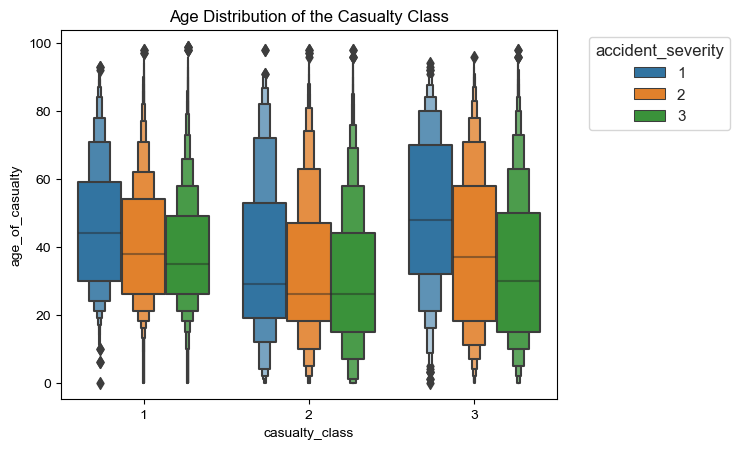

In [22]:
# Plot a boxenplot to explore the relationship between 'casualty_class' and age_of_casualty
sns.boxenplot(x ='casualty_class', y = 'age_of_casualty', data = EDA_data, hue ='accident_severity')
sns.set(style = 'whitegrid')
plt.legend(bbox_to_anchor=(1.05, 1), loc= 2,  title='accident_severity')
plt.title('Age Distribution of the Casualty Class');

 - This boxenplot above shows the median age for casualty-class 1 (drivers/riders) involved in fatal accidents to be 45 years, 30 years for casualty-class 2 (Veh/pillion passengers), and 50 years for casualty-class 3 (pedestrians)
 - for serious accidents, it is 38 years for casualty-class 1 (drivers/riders), 27 years for class 2 (Veh/pillion passengers) and 37 years for casualty-class 3 (pedestrians).
 - for those involved in slight accidents, it is 35 for casualty-class 1 (drivers/riders), 25 for casualty-class 2 (Veh/pillion passengers) and 30 for casualty-class 3 (pedestrians).
- 75% of drivers/riders who had fata accidents are less tha 60 years of age with outliers at below 20 years of age. While, 75% of passengers who had fatal accidents are less than 55 years. The plot also indicates that pedestrians has the highest number of older people(above 65 years) involved in fatal accidents compared to the other two classes of casualties, while 25% of pedestrians who had fatal accidents are 30 years old or less. 

###### Relationship between casualty class and age of driver 

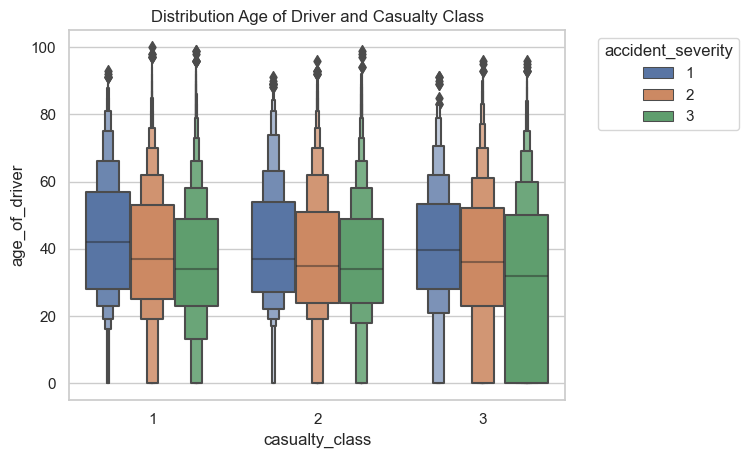

In [23]:
# Plot a boxenplot to explore the relationship between 'casualty_class' and age_of_driver
sns.boxenplot(x ='casualty_class', y = 'age_of_driver' , data = EDA_data, hue ='accident_severity')
sns.set(style = 'whitegrid')
plt.legend(bbox_to_anchor=(1.05, 1), loc= 2, title='accident_severity')
plt.title('Distribution Age of Driver and Casualty Class');

 - The boxenplot above demontrates the median age for drivers involved fatal accidents to be 45, 35 and 40 for casualty class 1, 2, and 3 respectively.
 - Drivers involved in slight accidents with casualty-class 3 (pedestrians); The plot above indicated that the median age of drivers involved in slight accidents with casualty-class 3(pedestrians) to be 30. 75% of these drivers are less than 50 years of age, 50% less than 30 years. And 25% of these drivers were documented as -1 (unknown). The high percentage of unknown drivers involved in accidents to pedestrians may be indicative of hit and run, where the casualty may incapable of identifying and reporting the driver.
 - Also the smaller number of unknown drivers in accidents in casualty_class 1 and 2, demonstrates that the most drivers are also casualties in the accidents they are involved in.
  - Disregarding the unknowns at casualty_class 3 (pedestrians), the thickness (the 25% and 75% range) of all the boxes shows that the people most likely to involve in an accident are between the ages of 25 and late 50s.

_______________________________________________________________________________________________________

### Exercise No. 1 
- Are there significant hours of the day, and days of the week, on which accidents occur?

###### Significant hours of the day in which accidents occur
- To examine the the hour(s) of the day in which most accidents occur, a temporarily feature (n_time) was created as a datetime64[ns]object from the time feature, to enable analysis of accidents that occured in each hour of the day.

In [24]:
"""
Temporarily create a duplicate of the time column and format the duplicate to a datetime64[ns]object, 
then instantiate a variable (acc_time) to group the duplicate into 24 hr period using dt.hour 
and count the number of acidents per hour  
"""

acc_df['n_time'] = acc_df['time']
acc_df['n_time'] = pd.to_datetime(acc_df['n_time']) 
acc_n_time = acc_df.groupby(acc_df['n_time'].dt.hour)
acc_n_time = acc_n_time['accident_reference'].count()
acc_n_time.index = [f"{hour:02}:00" for hour in acc_n_time.index]

###### Visualizing  significant hours of the day in which accidents occur

In [25]:
# print number  of accidents per hour 
acc_n_time 

00:00    1188
01:00     915
02:00     658
03:00     566
04:00     508
05:00     855
06:00    1830
07:00    3736
08:00    5267
09:00    3917
10:00    4173
11:00    4812
12:00    5395
13:00    5741
14:00    6245
15:00    7361
16:00    7381
17:00    7813
18:00    6618
19:00    5048
20:00    3715
21:00    3106
22:00    2555
23:00    1796
Name: accident_reference, dtype: int64

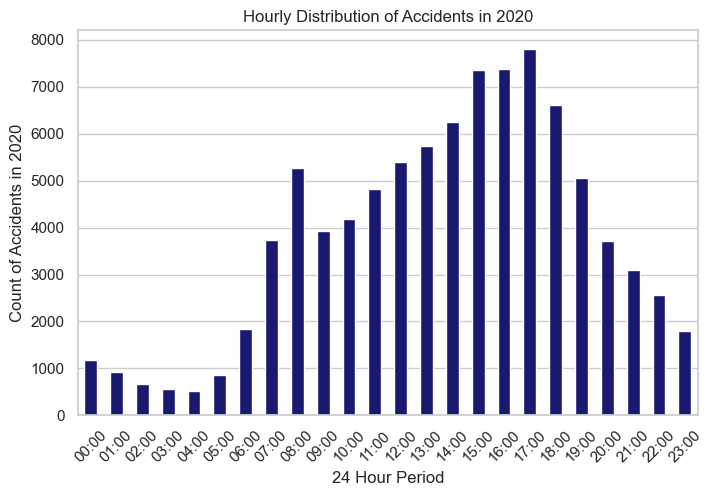

In [26]:
# Plotting a barchart for the number of accidents that occured in each in 2020

plt.figure(figsize=(8, 5))
acc_n_time.plot(kind='bar',color='midnightblue') 
plt.xlabel('24 Hour Period')
plt.ylabel('Count of Accidents in 2020')
plt.title('Hourly Distribution of Accidents in 2020')
plt.grid(which='major', axis = 'x', linewidth=0.0)
plt.xticks(rotation=45);

###### Significant days of the week in which accidents occur

- To examine the  day(s) of the week with significant number of accidents, two temporary features ('n_time' and 'Days_of_the_Week') was created as a datetime64[ns]object for ease of analysis. Note that a similar feature (days_of_week), that represents the days of the week in numbers, already exist in the Accident table. However, 'Days_of_the_Week' as created, makes for a better presentation by depicting the actual names of the day.

In [27]:
# create two new columns ('n_date' and 'Days_of_the_Week') from 'date' column to translate the date column as names of weekday 
acc_df["n_date"] = pd.to_datetime(acc_df['date'], dayfirst = True)
acc_df['Days_of_the_Week'] = acc_df['n_date'].dt.day_name()

###### Visualizing the number of accidents by days of the week 

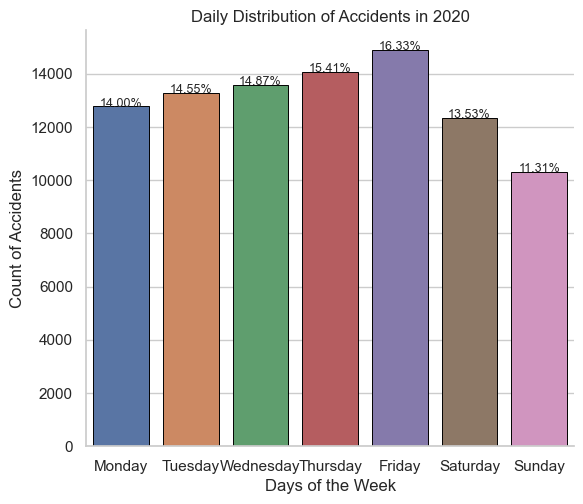

In [28]:
# Make a list of days of the week to start staring from Monday 
days_of_wk = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday','Sunday']
sum_accidents = len(acc_df['accident_index'])


# Visualise the plot and add percentages
plot = sns.catplot(data=acc_df, x ="Days_of_the_Week", kind = "count", aspect=1.2, order=days_of_wk, edgecolor="black", linewidth=0.7)
sns.set(style="whitegrid")       
for i in plot.axes.flat:
    for perc in i.patches:
        percentage = perc.get_height() / sum_accidents * 100
        i.annotate(f'{percentage:.2f}%', (perc.get_x() + perc.get_width() / 2., perc.get_height()), ha='center', fontsize=9)       
plt.xlabel('Days of the Week')
plt.ylabel('Count of Accidents')
plt.title('Daily Distribution of Accidents in 2020');

In [29]:
# count of accidents per week day
acc_df['Days_of_the_Week'].value_counts()

Friday       14889
Thursday     14056
Wednesday    13564
Tuesday      13267
Monday       12772
Saturday     12336
Sunday       10315
Name: Days_of_the_Week, dtype: int64

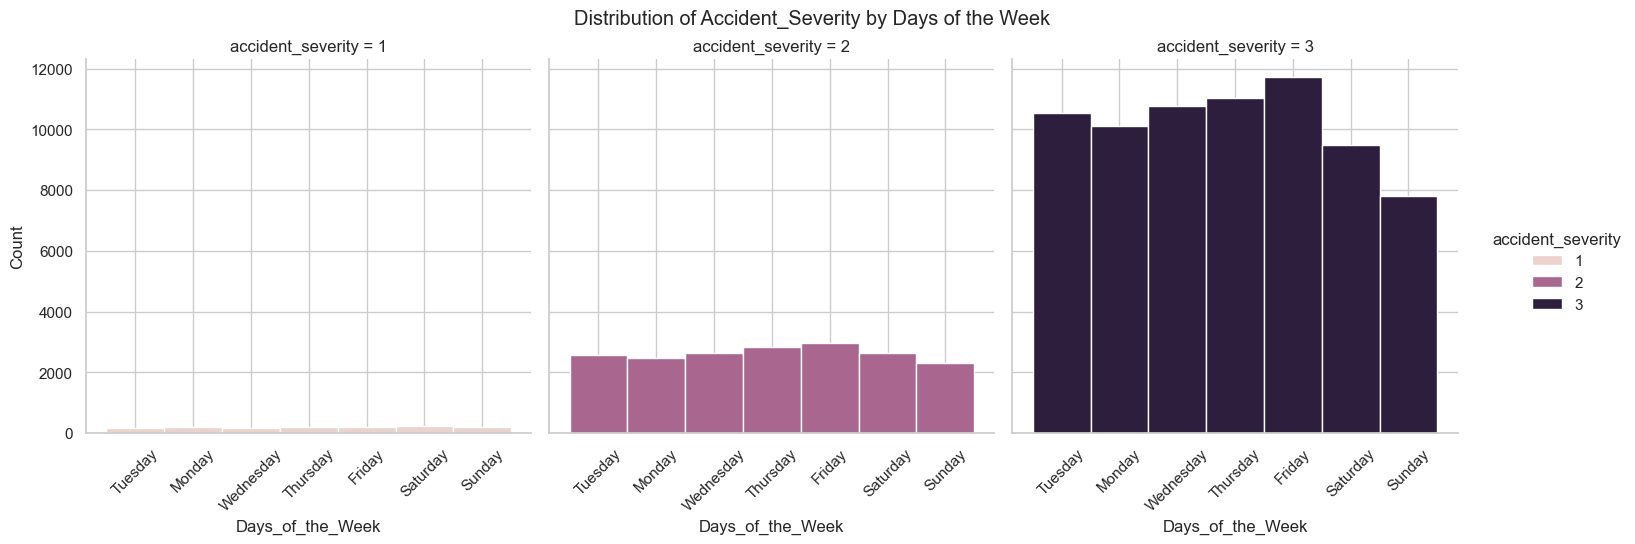

In [30]:
# Plotting the 3 levels of accident severity for the days of the week  
acc_sev_chart = sns.displot(x ='Days_of_the_Week', data = acc_df, kind = 'hist', hue = 'accident_severity', 
                            col = 'accident_severity',alpha = 1)
acc_sev_chart.set_xticklabels(rotation=45)
plt.subplots_adjust(top=0.88)
plt.suptitle('Distribution of Accident_Severity by Days of the Week');

In [31]:
# Investigating the severity of accident that occurred per hour 

acc_n_time = acc_df.groupby(acc_df['n_time'].dt.hour)['accident_severity'].value_counts()
acc_n_time

n_time  accident_severity
0       3                     857
        2                     291
        1                      40
1       3                     645
        2                     236
        1                      34
2       3                     449
        2                     170
        1                      39
3       3                     407
        2                     129
        1                      30
4       3                     358
        2                     125
        1                      25
5       3                     602
        2                     219
        1                      34
6       3                    1381
        2                     409
        1                      40
7       3                    2985
        2                     716
        1                      35
8       3                    4332
        2                     883
        1                      52
9       3                    3169
        2             

###### Interpretation and Analysis 
- Most accidents in 2020 occured around 5pm, a total of 7,813 occurrences, followed by 4pm with 7,380 and 3pm with 7,361 incidents. The least number of accidents occurred around 4am with a total number of 508 incidents. This Increased by 68% to 854 by 5am, from 5am it increased by 114% to 1830 by 6am, and at 104% from 6am to 7am to peak at 8am at a count of 5267. It then dropped from 8am to 9am by 25%, before resuming another steady incline from 9am till 5pm. This corresponds with the time the roads are expected to be busy. In summary, there are more number of accidents during the daytime, from 8am and 7pm than in the evening 8pm to 7am. 
- Friday recorded the highest number of accidents, a total of 14,886, with Sunday recording the lowest number of accidents. The chart showed a steady increase of accidents from Monday peaking at Friday before dropping drastically on Saturday, and flattening on Sunday.
- The third graph 'Distribution of Accident_Severity by Days of the Week' indicates that fatal accidents have the least occurrences, followed by serious accidents and a greater number of slight accidents. This anlayses of accidents by severity is also reflective of total number of accidents by days of the week.
- In summary, most accidents occur between 3pm and 5pm, and most accidents occur during the weekday(workday) than on weekends. 

_____________________________________________________________________________________________________

### Exercise No. 2
- For motorcycles, are there significant hours of the day, and days of the week, on which accidents occur? We suggest a focus on: Motorcycle 125cc and under, Motorcycle over 125cc and up to 500cc, and Motorcycle over 500cc.

- To answer this question, we will first filter the Vehicle table to consist of only the suggested motorcycles, and since we do not have date or time in the Vehicle table, we need to merge Vehicle table with Accident table. Then use the temporary columns(n_time, n_date and Days_of_the_Week)  created for these time-based questions to also address this question.

In [32]:
# Merge vehicle table with accident table
acc_veh_mbj = pd.merge(acc_df, veh_df, on = 'accident_index')

In [33]:
# Creating a list of the suggested motorcycles
motorcycles = []
for i in veh_df['vehicle_type']:
    if i == 3:
        motorcycles.append(i)
    elif i == 4:
        motorcycles.append(i)
    elif i == 5:
        motorcycles.append(i)     

In [34]:
# filtering the vehicle table to include only the suggested motocycles 
veh_mb = veh_df[veh_df['vehicle_type'].isin(motorcycles)]

In [35]:
# Merge the two tables on the accident_index, a column that is present in the two tables
acc_veh_mbj = pd.merge(acc_df, veh_mb, on = 'accident_index')

In [36]:
# checking
acc_veh_mbj.head(2)

,accident_index,accident_year_x,accident_reference_x,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_district,local_authority_ons_district,local_authority_highway,first_road_class,first_road_number,road_type,speed_limit,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,n_time,n_date,Days_of_the_Week,vehicle_index,accident_year_y,accident_reference_y,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane,junction_location,skidding_and_overturning,hit_object_in_carriageway,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,vehicle_left_hand_drive,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,driver_home_area_type
0,2020010228020,2020,010228020,529718.0,192342.0,-0.12784,51.614971,1,3,2,1,01/01/2020,4,03:25,32,E09000010,E09000010,3,406,3,30,6,2,3,406,0,5,4,1,1,0,0,1,1,2,E01001530,2023-08-29 03:25:00,2020-01-01,Wednesday,681728,2020,010228020,1,3,0,3,7,3,0,1,0,0,0,0,2,1,6,1,37,7,114,1,5,YAMAHA XC115,8,1
1,2020010228086,2020,010228086,531043.0,176304.0,-0.11468,51.470537,1,3,1,1,01/01/2020,4,14:00,9,E09000022,E09000022,6,0,6,20,0,-1,0,-1,0,0,1,1,1,0,0,1,1,2,E01003186,2023-08-29 14:00:00,2020-01-01,Wednesday,681749,2020,010228086,1,3,0,18,7,3,9,0,0,11,0,0,1,1,6,3,-1,-1,-1,-1,-1,-1,-1,-1


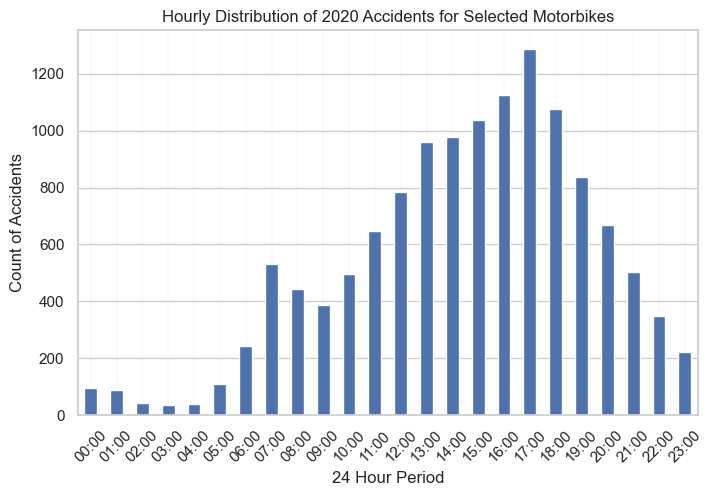

In [37]:
# Plotting the number of accidents per hour for the selected motorcycles 
acc_t = acc_veh_mbj.groupby(acc_veh_mbj['n_time'].dt.hour)
acc_t = acc_t['accident_index'].count()
acc_t.index = [f"{hour:02}:00" for hour in acc_t.index]

# Plotting the barchart  
plt.figure(figsize=(8, 5))
acc_t.plot(kind='bar')
plt.xlabel('24 Hour Period')
plt.ylabel('Count of Accidents')
plt.title('Hourly Distribution of 2020 Accidents for Selected Motorbikes')
plt.grid(which='major', axis = 'x', linewidth=0.1)
plt.xticks(rotation=45);

In [38]:
# Number of accidents involving the 3 selected vehicle types
acc_t

00:00      96
01:00      90
02:00      43
03:00      37
04:00      41
05:00     111
06:00     243
07:00     531
08:00     445
09:00     388
10:00     497
11:00     648
12:00     786
13:00     961
14:00     976
15:00    1038
16:00    1126
17:00    1288
18:00    1075
19:00     836
20:00     669
21:00     504
22:00     348
23:00     221
Name: accident_index, dtype: int64

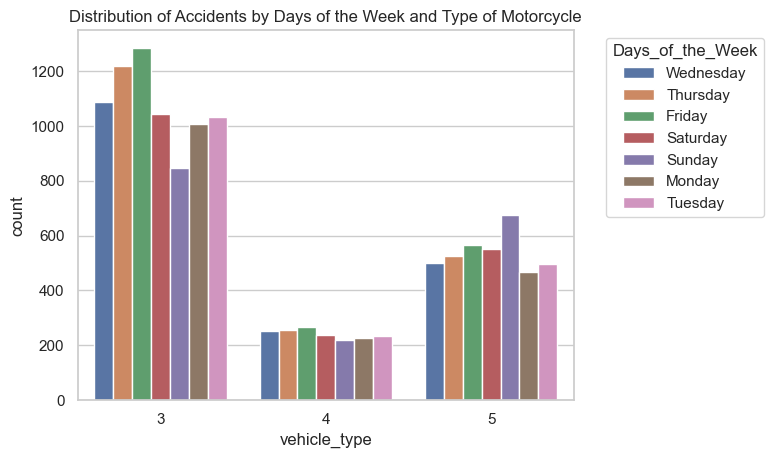

In [39]:
# Distribution of accident week involving the selected motorcycles by days of the week

sns.countplot(data= acc_veh_mbj, x = 'vehicle_type', hue='Days_of_the_Week')

plt.legend(bbox_to_anchor=(1.05, 1), loc= 2, title='Days_of_the_Week')
plt.title('Distribution of Accidents by Days of the Week and Type of Motorcycle');

In [40]:
# Number of Accidents per Days of the Week for the selected motorcycles
acc_veh_mbj['Days_of_the_Week'].value_counts()

Friday       2119
Thursday     2002
Wednesday    1841
Saturday     1830
Tuesday      1765
Sunday       1738
Monday       1703
Name: Days_of_the_Week, dtype: int64

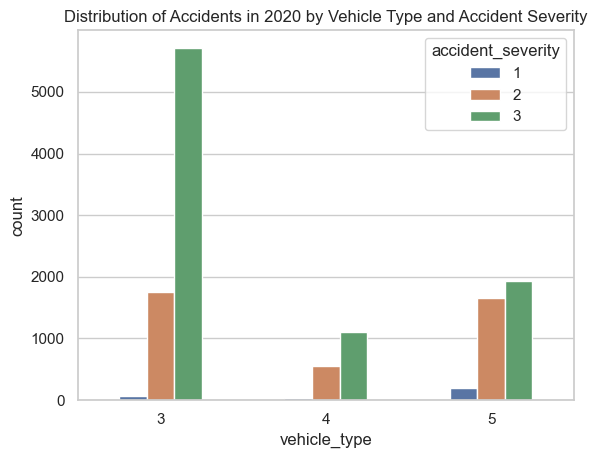

In [41]:
# Plotting the number of the 3 levels of accident severity for each of the selected morocycles  
veh_sev_chart = sns.countplot(x = 'vehicle_type',data = acc_veh_mbj, hue = 'accident_severity', width=0.5)
plt.title('Distribution of Accidents in 2020 by Vehicle Type and Accident Severity');

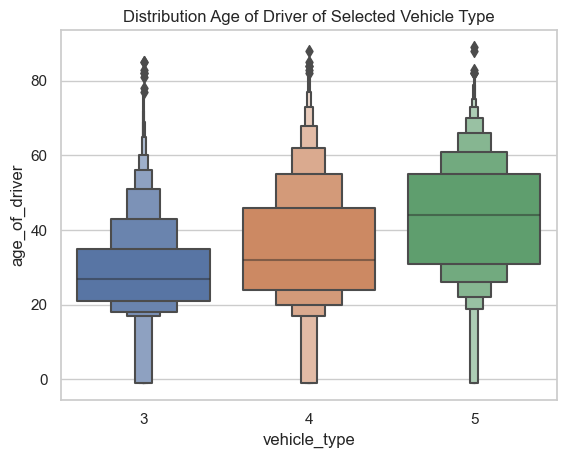

In [42]:
sns.boxenplot(x ='vehicle_type', y = 'age_of_driver' , data = acc_veh_mbj)
sns.set(style = 'whitegrid')
plt.title('Distribution Age of Driver of Selected Vehicle Type');

###### Analysis and Interpretation 
 - From observing the trend from the first chart above, it is clear that vehicle type 3 (M/cycle 125cc and under) was involved in the highest number of accident, followed by vehicle type 5(M/cycle over 500cc). Vehicle type 4 (Motorcycle over 125cc and up to 500cc) is involved in the least number of accidents. This may be as a result of the age bracket of majority of its riders; 25 to 45 years. It can be assumed that this age bracket is balancing good experience with a moderate sized motorcycle (the higher the cc of a bike, the more difficult it will handle). This vehicle type also recorded the least of fatal accidents.
 - The chart showing the age distribution of vehicles type shows that the smaller the cc of the motorcycle the younger tje riders. This is typical as riders tend to prefer bigger engine as they grow in experience. 
 - The way count of accidents is distributed across hours is reflective of the total number of accidents in the entire dataset. Most accidents occur around 5pm, with least number of accidents occuring around around 2am, same with the enire dataset, there is a spike from 6am to 7am, dropping down gradually rising till it peaked at 5pm. 
 - Overall, the number of fatal accidents by the selected vehicle type is actually contributing 14% to the total number of accidents, vehicle type 4(Motorcycle over 125cc and up to 500cc) recording the lowest number.
 - The chart of Vehicle type and accident severity demontrates that the majority of accidents involving this motorcycles are of the slight severity. 

### Exercise No.3
- For pedestrians involved in accidents, are there significant hours of the day, and days of the week, on which they are more likely to be involved?

- For this question we will first merge accident, vehicle and casualty, then filter for pedestrians in casualty class 3  

In [43]:
# Merging accident, vehicle and casualty tables  
acc_veh_jn = pd.merge(acc_df, veh_df, on = 'accident_index')
acc_veh_cas_jn = pd.merge(acc_veh_jn, cas_df, on = 'accident_index')

In [44]:
# Filter the acc_veh_cas_jn to include accidents involving only pedestrians 
pedestrian_df = acc_veh_cas_jn[(acc_veh_cas_jn['casualty_class'] == 3)]

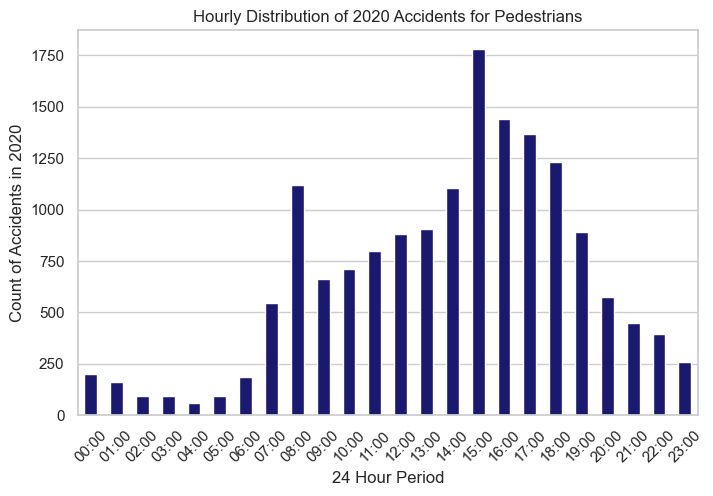

In [45]:
# to plot the graph I need to group the n_time column into 24 hour format using .dt.hour

pedestrians = pedestrian_df.groupby(pedestrian_df['n_time'].dt.hour)
pedestrians = pedestrians['accident_index'].count()
pedestrians.index = [f"{hour:02}:00" for hour in pedestrians.index]


# plot the graph on the instantiated variable; 'pedestrian'
plt.figure(figsize=(8, 5))
pedestrians.plot(kind='bar',color= 'midnightblue') 
plt.xlabel('24 Hour Period')
plt.ylabel('Count of Accidents in 2020')
plt.title('Hourly Distribution of 2020 Accidents for Pedestrians')
plt.grid(which='major', axis = 'x', linewidth=0.0)
plt.xticks(rotation=45);

In [46]:
# Number of accidents per hour involving pedestrians
pedestrians

00:00     199
01:00     164
02:00      92
03:00      95
04:00      58
05:00      92
06:00     186
07:00     544
08:00    1119
09:00     664
10:00     712
11:00     797
12:00     881
13:00     907
14:00    1106
15:00    1783
16:00    1441
17:00    1366
18:00    1230
19:00     893
20:00     577
21:00     448
22:00     395
23:00     261
Name: accident_index, dtype: int64

In [47]:
# Total number of accidents by pedestrian
pedestrian_df['casualty_class'].value_counts()

3    16010
Name: casualty_class, dtype: int64

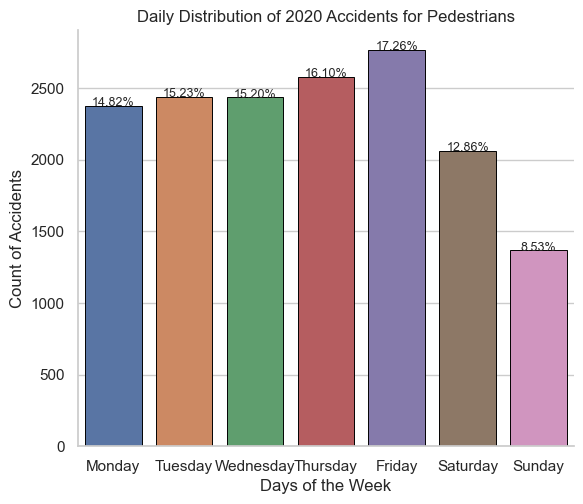

In [48]:
# visualization
days_of_wk = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday','Sunday']
sum_accidents = len(pedestrian_df['accident_index'])


# Visualise the plot and add percentages
plot = sns.catplot(data=pedestrian_df, x ="Days_of_the_Week", kind = "count", aspect=1.2, order=days_of_wk, edgecolor="black", linewidth=0.7)
sns.set(style="whitegrid")

for e in plot.axes.flat:
    for perc in e.patches:
        percentage = perc.get_height() / sum_accidents * 100
        e.annotate(f'{percentage:.2f}%', (perc.get_x() + perc.get_width() / 2., perc.get_height()), ha='center', fontsize=9)       
plt.xlabel('Days of the Week')
plt.ylabel('Count of Accidents')
plt.title('Daily Distribution of 2020 Accidents for Pedestrians');


In [49]:
# Number of Acciddents per Days of the Week
pedestrian_df['Days_of_the_Week'].value_counts()

Friday       2764
Thursday     2577
Tuesday      2439
Wednesday    2433
Monday       2372
Saturday     2059
Sunday       1366
Name: Days_of_the_Week, dtype: int64

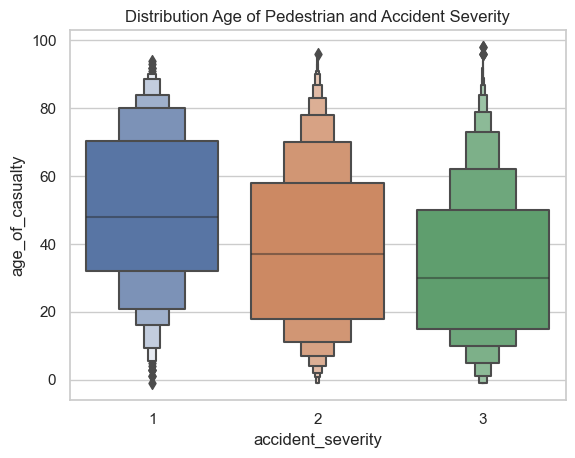

In [50]:
sns.boxenplot(x ='accident_severity', y = 'age_of_casualty' , data = pedestrian_df)
sns.set(style = 'whitegrid')
plt.title('Distribution Age of Pedestrian and Accident Severity');

###### Analysis and  Interpretation
   - Similar to exercise 1 and 2, Friday and Sunday have the highest and lowest number of accidents for pedestrians. This reduces the likelihood that these numbers may be biased as a result of an unproportionate contribution by a few or single category. Also, like the previous analysis, the highest number of accidents in the morning occurred around 8am. However, the highest number of accidents for pedestrians occurred around 3pm in contrast to 5pm for the whole dataset. Overall, the trend is very similar in both exercise 1, 2 and 3, with number of accidents increasing gradually from Monday, reaching its highest point on Friday and dropping to its lowest on Sunday.
- An interesting discovery of the Age of Pedestrian and Accident Severity chart is that older people make up the majority of pedestrians involved in fatal accidents. Age group of pedestrians reduces with the severity of accidents, i.e., the older the pedestrian is the more likely they will be in a serious or fatal accident.


In [51]:
# Columns created for datetime analysis in order to return the Accident Table to its original form is now dropped returning the Accident Table to 36 columns
# Make a copy of the dataframe with 'datetime','name_of_weekday','n_time' to save it for future analysis
acc_dfcopy = acc_df.copy()

In [52]:
# drop columns created for datetime analysis in order to return the Accident Table to its original form 
drop_cols = ['Days_of_the_Week', 'n_time', 'n_date']
acc_df = acc_df.drop(drop_cols, axis =1)

_____________________________________________________________________________________________

### Exercise No. 4
- Using the apriori algorithm, explore the impact of selected variables on accident severity.  

- Addressing this question involves the following approach;
    - Identify accident_severity as the target. 
    - Select the variables that are much likely to impact on accident_severity.
    - Merging the dataset on accident_index and lsoa_of_accident_location were selected to enable merging of the tables 

##### Selecting Features for Apriori Algorithm and Building of Model

In [53]:
# selecting variables from each table to explore their impact on accident_severity.
# include accident_index and 'lsoa_of_accident_location' to enable join

# make a list to collect the selected features 
acc_sv = ['accident_index','accident_severity','number_of_vehicles', 'number_of_casualties', 'road_type', 'speed_limit', 'light_conditions', 'weather_conditions', 'road_surface_conditions','lsoa_of_accident_location'] 
veh_sv = ['accident_index','vehicle_type', 'sex_of_driver', 'age_of_driver', 'engine_capacity_cc', 'age_of_vehicle']
cas_sv = ['accident_index', 'casualty_class', 'age_of_casualty', 'sex_of_casualty','casualty_severity','casualty_type','pedestrian_location']

# apply the list to the dataframe of the tables 
accsv_df = acc_df[acc_sv]
vehsv_df = veh_df[veh_sv]
cassv_df = cas_df[cas_sv]

###### Joining the selected features to make one table 

In [54]:
# Joining accsv_df and vehsv_df at accident_index'
acc_veh_j =  accsv_df.merge(vehsv_df, on = 'accident_index')

In [55]:
# Joining acc_veh_j and cassv_df at accident_index'
acc_veh_cas_j = acc_veh_j.merge(cassv_df, on = 'accident_index')

In [56]:
acc_veh_cas_j.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 220435 entries, 0 to 220434
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   accident_index             220435 non-null  object
 1   accident_severity          220435 non-null  int64 
 2   number_of_vehicles         220435 non-null  int64 
 3   number_of_casualties       220435 non-null  int64 
 4   road_type                  220435 non-null  int64 
 5   speed_limit                220435 non-null  int64 
 6   light_conditions           220435 non-null  int64 
 7   weather_conditions         220435 non-null  int64 
 8   road_surface_conditions    220435 non-null  int64 
 9   lsoa_of_accident_location  220435 non-null  object
 10  vehicle_type               220435 non-null  int64 
 11  sex_of_driver              220435 non-null  int64 
 12  age_of_driver              220435 non-null  int64 
 13  engine_capacity_cc         220435 non-null  

- Since Appriori algorithm accepts only one hot encoded features, I need to modify the data further by dropping all the continous variables and then apply one hot encoding on the categorical variables.

In [57]:
# drop all the continous variables 

aprio_df = acc_veh_cas_j.drop(['accident_index', 'sex_of_casualty', 'sex_of_driver', 'number_of_vehicles', 'number_of_casualties', 
            'lsoa_of_accident_location', 'age_of_driver', 'engine_capacity_cc', 'age_of_vehicle', 'age_of_casualty', 'casualty_severity'], axis = 1)

In [58]:
aprio_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 220435 entries, 0 to 220434
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   accident_severity        220435 non-null  int64
 1   road_type                220435 non-null  int64
 2   speed_limit              220435 non-null  int64
 3   light_conditions         220435 non-null  int64
 4   weather_conditions       220435 non-null  int64
 5   road_surface_conditions  220435 non-null  int64
 6   vehicle_type             220435 non-null  int64
 7   casualty_class           220435 non-null  int64
 8   casualty_type            220435 non-null  int64
 9   pedestrian_location      220435 non-null  int64
dtypes: int64(10)
memory usage: 18.5 MB


In [59]:
# encoding the features of the data 
def encoding(x):
    if x <= 1:
        return 0
    
    else:
        return 1

In [60]:
aprio_encoded = aprio_df.applymap(encoding)

In [61]:
aprio_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 220435 entries, 0 to 220434
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   accident_severity        220435 non-null  int64
 1   road_type                220435 non-null  int64
 2   speed_limit              220435 non-null  int64
 3   light_conditions         220435 non-null  int64
 4   weather_conditions       220435 non-null  int64
 5   road_surface_conditions  220435 non-null  int64
 6   vehicle_type             220435 non-null  int64
 7   casualty_class           220435 non-null  int64
 8   casualty_type            220435 non-null  int64
 9   pedestrian_location      220435 non-null  int64
dtypes: int64(10)
memory usage: 18.5 MB


In [62]:
aprio_encoded.head()

,accident_severity,road_type,speed_limit,light_conditions,weather_conditions,road_surface_conditions,vehicle_type,casualty_class,casualty_type,pedestrian_location
0,1,1,1,0,1,1,1,1,0,1
1,1,1,1,0,0,0,1,1,0,0
2,1,1,1,0,0,0,1,1,0,0
3,1,1,1,1,0,1,1,1,0,1
4,1,1,1,1,0,0,1,1,0,1


##### Implementing Apriori Algorithm

In [63]:
from mlxtend.frequent_patterns import apriori, association_rules

In [64]:
# converting dataframe to boolean type 
def boolean (b):
    return bool(b)
aprio_encoded = aprio_encoded.applymap(boolean)

In [65]:
# instantiate apriori algorithm as frequent_items 
frequent_items = apriori(aprio_encoded, min_support = 0.05, use_colnames = True)

# print the frequent items 
frequent_items

,support,itemsets
0,0.980806,(accident_severity)
1,0.943661,(road_type)
2,0.999936,(speed_limit)
3,0.289396,(light_conditions)
4,0.219108,(weather_conditions)
5,0.311584,(road_surface_conditions)
6,0.920802,(vehicle_type)
7,0.267675,(casualty_class)
8,0.780198,(casualty_type)
9,0.061306,(pedestrian_location)


In [66]:
# find the association rules in the frequent items  
associatn_rules = association_rules(frequent_items, metric = 'confidence', min_threshold = 0.7)

# print the association rules 
associatn_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(accident_severity),(road_type),0.980806,0.943661,0.924685,0.942781,0.999067,-8.636044e-04,0.984612,-0.046401
1,(road_type),(accident_severity),0.943661,0.980806,0.924685,0.979891,0.999067,-8.636044e-04,0.954490,-0.016307
2,(accident_severity),(speed_limit),0.980806,0.999936,0.980743,0.999935,0.999999,-1.219018e-06,0.980806,-0.000065
3,(speed_limit),(accident_severity),0.999936,0.980806,0.980743,0.980805,0.999999,-1.219018e-06,0.999936,-0.019195
4,(light_conditions),(accident_severity),0.289396,0.980806,0.282129,0.974888,0.993966,-1.712821e-03,0.764316,-0.008471
5,(weather_conditions),(accident_severity),0.219108,0.980806,0.215161,0.981987,1.001204,2.587818e-04,1.065568,0.001540
6,(road_surface_conditions),(accident_severity),0.311584,0.980806,0.304466,0.977156,0.996279,-1.137244e-03,0.840224,-0.005397
7,(accident_severity),(vehicle_type),0.980806,0.920802,0.902366,0.920025,0.999156,-7.625219e-04,0.990279,-0.042169
8,(vehicle_type),(accident_severity),0.920802,0.980806,0.902366,0.979978,0.999156,-7.625219e-04,0.958640,-0.010557
9,(casualty_class),(accident_severity),0.267675,0.980806,0.261002,0.975070,0.994152,-1.535445e-03,0.769908,-0.007969


- A brief explanation of the concepts of apriori algorithm as related this dataset
   
    - Support: No. of events involving a particular event divided by the total number of events
        - High support value means events that frequently occur together.
        - Low support means that the events do not frequently occur together 
    - Confidence: Support for the event A divided by support for event B
        - High confidence value means the consequence are frequently found when the Antecedent is present 
    - Lift: A measure of how much likely a Consequence will appear when the Antecedent is present
        - Lift values that is greater than 1 indicates a strong association between the Consequence and the Antecedent, that is, the present of the Antecedent indicates the likelyhood of finding the Consequence.
        - Lift values that are equal to 1 means that there is no relationship between the 2 events under consideration
        - Lift values less than 1 means a negative relationship, the ocurrence of one event indicates the non-occurrence of the other
    - Conviction checks the frequency of the incorrect prediction. It asks does the Antecedent occur without Consequence.


#### Analysis and Interpretation
Analysis of the association rules above is focused on data points where accident_severity is the consequent, since the task is to explore impact of the selected variables (the antecedents) on the accident_severity (the consequent).
Notice that the tables have very high confidence values, meaning that the accident is frequently found where the various selected variables (antecedents) like speed_limit, road_type, whether_conditions, etc is present. It is also evident that support (a metric that measures events that frequently occur together) is high in most of the observations, except in areas like pedestrian_location vs accident_severity and some few others. 

In contrast, most values under lift are 1 or close to 1, there are no lift values that are more than 1. Note that lift measures how much likely a Consequence will appear when the Antecedent is present. Lift values that is greater than 1 indicates a strong association between the Consequence and the Antecedent, Lift values that are equal to 1 means that there is no relationship between the 2 events under consideration. Lift values less than 1 means a negative relationship, the occurrence of one event indicates the non-occurrence of the other. Similarly, Zhangs metric, an extension of the lift metric that measures the association/dissociation between variables, is mostly negative. A negative Zhang metric (-1: perfect dissociation) indicates lack of association while a positive Zhang metric (1: perfect association) indicates association (Bismi, 2023).

Despite the high values for Support snd Confidence suggesting that there is a relationship between accident_severity and the selected variables, lift and Zhangs _metric indicate the opposite. This suggests that although the presence of the selected variables influence the occurrence of accident, it does not necessarily influence the severity of the accidents that occurred.


____________________________________________________________________________________________________________________________

### Exercise No. 5
- Identify accidents in our region: Kingston upon Hull, Humberside, and the East Riding of Yorkshire etc. You can do this by filtering on LSOA, or police region or another method if you can find one. Run clustering on this data. What do these clusters reveal about the distribution of accidents in our region? 

- Humberside region is comprised of four unitary authorities: North Lincolnshire, North East Lincolnshire, Kingston upon Hull and East Riding of Yorkshire. Therefore, i will merge the four tables then filter for these for unitary authorities that using the lsoa1nm column.
- I am using the K-Means method to run clustering on this data


In [67]:
# import necessary libraries for clustering

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [68]:
# Merging accident, vehicle and casualty tables  
acc_veh_jn = pd.merge(acc_df, veh_df, on = 'accident_index')
acc_veh_cas_jn = pd.merge(acc_veh_jn, cas_df, on = 'accident_index')

# then merge with lsoa Table 
AccVehCasLs_merged = acc_veh_cas_jn.merge(ls_df, left_on = 'lsoa_of_accident_location',
                                   right_on = 'lsoa01cd')

In [69]:
# Filter the AccVehCasLs_merged in Exercise 3 for Humberside, Kingston upon Hull and East Riding of Yorkshire
#AccOurRegion
HumberRegion_df = AccVehCasLs_merged[(AccVehCasLs_merged['lsoa01nm'].str.contains('Kingston upon Hull')) |
         AccVehCasLs_merged['lsoa01nm'].str.contains('East Riding of Yorkshire') |
        (AccVehCasLs_merged['police_force']== 16)]

In [70]:
# checking for the inclusion unitary authorities of Humberside 
HumberRegion_df['lsoa01nm'].str.contains('Hull|Yorkshire|Lincolnshire').sum()

3985

In [71]:
HumberRegion_df['lsoa01nm'].unique()

array(['Kingston upon Hull 028E', 'North Lincolnshire 022C',
       'Kingston upon Hull 002E', 'North East Lincolnshire 003C',
       'Kingston upon Hull 016D', 'North East Lincolnshire 016C',
       'Kingston upon Hull 026D', 'North Lincolnshire 006D',
       'East Riding of Yorkshire 014A', 'East Riding of Yorkshire 007H',
       'North East Lincolnshire 019A', 'East Riding of Yorkshire 033C',
       'Kingston upon Hull 019D', 'Kingston upon Hull 029D',
       'North Lincolnshire 012B', 'Kingston upon Hull 031D',
       'North Lincolnshire 004D', 'East Riding of Yorkshire 040D',
       'North Lincolnshire 001C', 'North East Lincolnshire 021B',
       'North East Lincolnshire 003B', 'East Riding of Yorkshire 014D',
       'Kingston upon Hull 027B', 'North Lincolnshire 005A',
       'North East Lincolnshire 004C', 'East Riding of Yorkshire 011F',
       'North East Lincolnshire 014D', 'North Lincolnshire 002A',
       'North East Lincolnshire 017B', 'North East Lincolnshire 016B',
    

In [72]:
HumberRegion_df.head(2)

,accident_index,accident_year_x,accident_reference_x,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_district,local_authority_ons_district,local_authority_highway,first_road_class,first_road_number,road_type,speed_limit,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,vehicle_index,accident_year_y,accident_reference_y,vehicle_reference_x,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane,junction_location,skidding_and_overturning,hit_object_in_carriageway,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,vehicle_left_hand_drive,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,driver_home_area_type,casualty_index,accident_year,accident_reference,vehicle_reference_y,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile,objectid,lsoa01cd,lsoa01nm,lsoa01nmw,shape__area,shape__length,globalid
83493,2020160914930,2020,160914930,506050.0,428813.0,-0.393424,53.744936,16,3,2,1,02/01/2020,5,11:20,228,E06000010,E06000010,6,0,6,30,6,2,6,0,0,5,1,1,1,0,0,1,1,2,E01012777,751054,2020,160914930,1,9,0,9,1,7,0,8,0,0,0,0,1,1,5,1,24,5,1248,1,11,HYUNDAI I10,6,3,530927,2020,160914930,1,1,1,1,24,5,3,0,0,0,0,0,9,3,6,12777,E01012777,Kingston upon Hull 028E,Kingston upon Hull 028E,356750.94548,3963.099631,4c068a55-c2d9-426c-9cfa-94742ef4a3ff
83494,2020160914930,2020,160914930,506050.0,428813.0,-0.393424,53.744936,16,3,2,1,02/01/2020,5,11:20,228,E06000010,E06000010,6,0,6,30,6,2,6,0,0,5,1,1,1,0,0,1,1,2,E01012777,751055,2020,160914930,2,19,0,5,5,1,0,1,0,0,0,0,1,1,1,1,48,8,1968,2,5,VOLKSWAGEN TRANSPORTER,7,1,530927,2020,160914930,1,1,1,1,24,5,3,0,0,0,0,0,9,3,6,12777,E01012777,Kingston upon Hull 028E,Kingston upon Hull 028E,356750.94548,3963.099631,4c068a55-c2d9-426c-9cfa-94742ef4a3ff


 - It will be diificult to conduct analysis on lsoa01nm as it appears. Therefore, the 4 unitary authorities of Humberside will be organizedby creaing an new column 'Our_Region' by removing all the unique codes attached the items in lsoa01nm 
 

In [73]:
# To group all the 4 unitary authorities in Humberside with their various lsoa codes into 4 by removing the codes 
for items in HumberRegion_df['lsoa01nm']:
    HumberRegion_df['Our_Region'] = HumberRegion_df['lsoa01nm'].str[:-5]

In [74]:
# checking 
HumberRegion_df['Our_Region'].value_counts()

Kingston upon Hull          1279
East Riding of Yorkshire    1188
North Lincolnshire           811
North East Lincolnshire      707
Name: Our_Region, dtype: int64

In [75]:
# make two copies of the dataset
HumberRegion_dfcopy = HumberRegion_df.copy()

In [76]:
HumberRegion_dfcopy2 = HumberRegion_df.copy()

##### Run clustering on the data to reveal the distribution of accidents in the  region.

In [77]:
# make a list to collect the selected features 
ls = ['accident_severity', 'number_of_casualties', 'number_of_vehicles',
      'age_of_casualty','age_of_driver', 'casualty_class']
HumberRegion_dfcopy = HumberRegion_dfcopy[ls]

In [78]:
HumberRegion_dfcopy.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3985 entries, 83493 to 87477
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   accident_severity     3985 non-null   int64
 1   number_of_casualties  3985 non-null   int64
 2   number_of_vehicles    3985 non-null   int64
 3   age_of_casualty       3985 non-null   int64
 4   age_of_driver         3985 non-null   int64
 5   casualty_class        3985 non-null   int64
dtypes: int64(6)
memory usage: 217.9 KB


In [79]:
HumberRegion_dfcopy.head()

,accident_severity,number_of_casualties,number_of_vehicles,age_of_casualty,age_of_driver,casualty_class
83493,3,1,2,24,24,1
83494,3,1,2,24,48,1
83495,3,1,2,61,34,1
83496,3,1,2,61,61,1
83497,3,1,2,59,22,1


In [80]:
HumberRegion_dfcopy.describe()

,accident_severity,number_of_casualties,number_of_vehicles,age_of_casualty,age_of_driver,casualty_class
count,3985.000000,3985.000000,3985.000000,3985.000000,3985.000000,3985.000000
mean,2.764115,1.660979,2.129737,35.648432,33.835132,1.303890
std,0.466301,1.136624,0.738011,19.857717,21.785663,0.569689
min,1.000000,1.000000,1.000000,-1.000000,-1.000000,1.000000
25%,3.000000,1.000000,2.000000,21.000000,21.000000,1.000000
50%,3.000000,1.000000,2.000000,33.000000,33.000000,1.000000
75%,3.000000,2.000000,2.000000,49.000000,49.000000,1.000000
max,3.000000,10.000000,7.000000,93.000000,93.000000,3.000000


In [81]:
# fill -1 in age with the median value or drop all rows

HumberRegion_dfcopy['age_of_casualty'].replace (-1, HumberRegion_dfcopy['age_of_casualty'].median(), inplace = True)


In [82]:
# instantiate standard scaler
scaler = StandardScaler()
HR_scaled = scaler.fit_transform(HumberRegion_dfcopy)

In [83]:
# Choose as initial number of clusters
kmeans = KMeans(random_state = 0, n_clusters=4)

In [84]:
kmeans.fit(HR_scaled)

KMeans(n_clusters=4, random_state=0)

In [85]:
# printing the clusters 
y_pred = kmeans.predict(HR_scaled)
print(y_pred)

[3 3 1 ... 3 3 3]


In [86]:
# using numpy function to print the unique number of clusters 
y_pred_unique = np.unique(y_pred)
print(y_pred_unique)

[0 1 2 3]


In [87]:
# calculate the silhouette score for k = 4
silhouette = silhouette_score(HR_scaled, y_pred)
print("Silhouette Score:", silhouette)

Silhouette Score: 0.22187994340733844


At n_clusters == 2, silhouette score is 0.2687027379759941
At n_clusters == 3, silhouette score is 0.2076817197534939
At n_clusters == 4, silhouette score is 0.22187994340733844
At n_clusters == 5, silhouette score is 0.24158250826482305
At n_clusters == 6, silhouette score is 0.2559679447436432
At n_clusters == 7, silhouette score is 0.2601811035716857
At n_clusters == 8, silhouette score is 0.21640479065777457
At n_clusters == 9, silhouette score is 0.22273380021915334


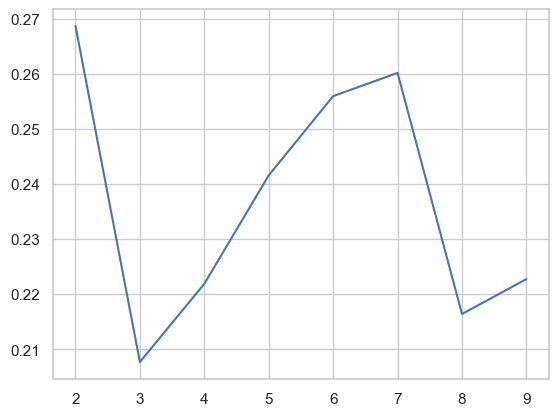

In [88]:
# Choosing the optimal number of clusters 
silhoutte_sc = []  
cluster_list = list(range(2, 10))  # Creating a list of range from 2 to 10
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters)  # Initializing KMeans algorithm
    y_pred = clusterer.fit_predict((HR_scaled))  # Predicting on the data
    score = silhouette_score(HR_scaled, y_pred) 
    silhoutte_sc.append(score)  # Append score to list 
    print("At n_clusters == {}, silhouette score is {}".format(n_clusters, score))

plt.plot(cluster_list, silhoutte_sc);

- Recalculate Kmeans based on the suggested optimal number of clusters 

In [89]:
kmeans = KMeans(random_state = 0, n_clusters=2)

In [90]:
kmeans.fit(HR_scaled)

KMeans(n_clusters=2, random_state=0)

In [91]:
# double checking the silhouette score for k = 2
silhouette = silhouette_score(HR_scaled, kmeans.labels_)
print("Silhouette Score:", silhouette)

Silhouette Score: 0.2687027379759941


In [92]:
# adding kmeans cluster labels to the original dataframe
HumberRegion_dfcopy["Kmeans_clusters"] = kmeans.labels_

In [93]:
# checking
HumberRegion_dfcopy.head()

,accident_severity,number_of_casualties,number_of_vehicles,age_of_casualty,age_of_driver,casualty_class,Kmeans_clusters
83493,3,1,2,24,24,1,0
83494,3,1,2,24,48,1,0
83495,3,1,2,61,34,1,0
83496,3,1,2,61,61,1,0
83497,3,1,2,59,22,1,0


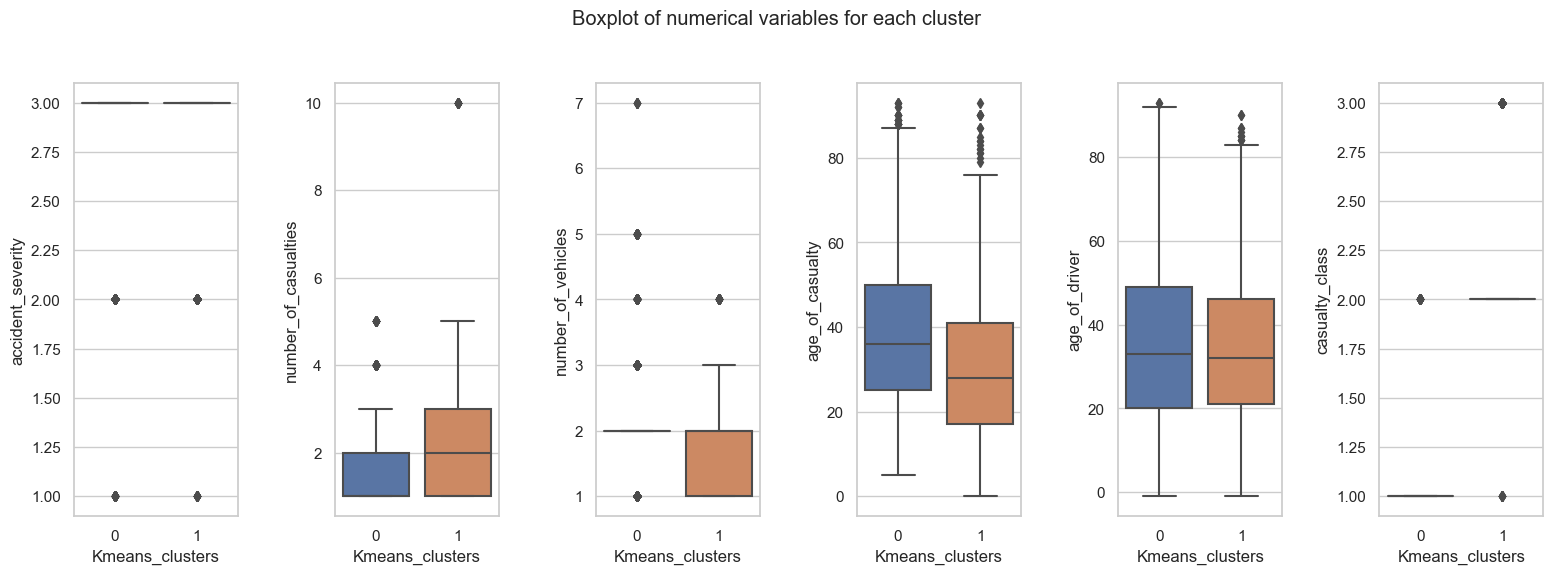

In [94]:
ls = ['accident_severity', 'number_of_casualties', 'number_of_vehicles', 'age_of_casualty','age_of_driver', 'casualty_class']

fig, axes = plt.subplots(1, 6, figsize=(16, 6))
fig.suptitle("Boxplot of numerical variables for each cluster")
counter = 0
for ii in range(6):
    sns.boxplot(ax=axes[ii], y=HumberRegion_dfcopy[ls[counter]], x=HumberRegion_dfcopy["Kmeans_clusters"])
    counter = counter + 1

fig.tight_layout(pad=2.0)

#### Analysis and Interpretation

- Based on the optimal number of clusters as calculated, the accidents in Humberside were clustered into 2 groups. There are some characteristics that are prevalent in the entire dataset therefore they are shared by the two groups. For example, the two groups mostly consist of slight accidents, with few that are serious and fatal. Other example are the age of casualty and age of driver. However, the groups differed on number of vehicles and casualty class. The first group has mainly casualty_class 1 (drivers/riders) as the majority of the casualties, with no pedestrian casualty in the group, while the second group is more of passengers with some drivers and pedestrians in the group too.

________________________________________________________________________________________________________

### Exercise No. 6 
- Using outlier detection methods, identify unusual entries in your data set. Should you keep these entries in your data? 
- Three methods of outlier detection methods were applied on the dataset filtered for Humber Region only 

###### Isolation Forest
- iForest builds on the notion outliers are rare circumstances that can be easily isolated from the rest of the data. It is build on an ensemble of isolation trees to achieve this isolation. It is an unsurpervised outlier detection algorithm that operates based on the idea of isolating outliers in a dataset. Unlike the the Z score method, you can parse in the whole dataset to check for outliers when working with isolation forest.

In [95]:
# drop the columns not needed 

cols_drop = ['accident_index','accident_year','accident_year_x', 'accident_reference_x', 'location_easting_osgr','location_northing_osgr',
'longitude','latitude', 'date', 'time', 'local_authority_district','local_authority_ons_district','local_authority_highway', 
'first_road_class', 'first_road_number','junction_detail','junction_control', 'second_road_class','second_road_number', 
'pedestrian_crossing_human_control', 'pedestrian_crossing_physical_facilities', 'special_conditions_at_site',
'carriageway_hazards','urban_or_rural_area','did_police_officer_attend_scene_of_accident', 'trunk_road_flag', 
'lsoa_of_accident_location','vehicle_index', 'accident_year_y', 'accident_reference_y', 'vehicle_reference_x', 
'towing_and_articulation', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to', 
'vehicle_location_restricted_lane', 'junction_location', 'skidding_and_overturning', 'hit_object_in_carriageway', 'journey_purpose_of_driver', 
'propulsion_code', 'generic_make_model', 'driver_imd_decile', 'driver_home_area_type', 'casualty_index', 'accident_year', 
'accident_reference', 'vehicle_reference_y', 'casualty_reference', 'pedestrian_movement', 'car_passenger', 
'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 
'casualty_type', 'casualty_home_area_type', 'casualty_imd_decile',  'objectid', 'lsoa01cd', 'lsoa01nm', 'lsoa01nmw', 
'shape__area', 'shape__length', 'globalid','vehicle_leaving_carriageway', 'hit_object_off_carriageway', 'first_point_of_impact',
'day_of_week','vehicle_left_hand_drive', 'age_band_of_casualty', 'age_band_of_driver' ]
HumberRegion_dfff = HumberRegion_df.drop(cols_drop, axis = 1)

In [96]:
# drop the features not needed and convert the Humber Region to one hot encoding

isofrst_df = HumberRegion_dfff.drop(['accident_severity'], axis = 1)

In [97]:
# convert the region to one hot encoded figure
isofrst_df  = pd.get_dummies(isofrst_df)

In [98]:
isofrst_df.head(3)

,police_force,number_of_vehicles,number_of_casualties,road_type,speed_limit,light_conditions,weather_conditions,road_surface_conditions,vehicle_type,sex_of_driver,age_of_driver,engine_capacity_cc,age_of_vehicle,casualty_class,sex_of_casualty,age_of_casualty,casualty_severity,pedestrian_location,Our_Region_East Riding of Yorkshire,Our_Region_Kingston upon Hull,Our_Region_North East Lincolnshire,Our_Region_North Lincolnshire
83493,16,2,1,6,30,1,1,1,9,1,24,1248,11,1,1,24,3,0,0,1,0,0
83494,16,2,1,6,30,1,1,1,19,1,48,1968,5,1,1,24,3,0,0,1,0,0
83495,16,2,1,3,30,1,1,2,9,2,34,1997,4,1,1,61,3,0,0,1,0,0


In [99]:
# Normalize the data
scaler = StandardScaler()
X = scaler.fit_transform(isofrst_df)

In [100]:
from sklearn.ensemble import IsolationForest

In [101]:
# create an instance of the model
iforest = IsolationForest(contamination= 0.07)
iforest.fit(X)
pred = iforest.predict(X)

In [102]:
isofrst_df['isofrst_outlier'] = pred

In [103]:
# show the outliers
isofrst_df[isofrst_df['isofrst_outlier'] ==-1].sum()

police_force                             4464
number_of_vehicles                        499
number_of_casualties                      452
road_type                                1414
speed_limit                             11190
light_conditions                          741
weather_conditions                        678
road_surface_conditions                   393
vehicle_type                             6228
sex_of_driver                             503
age_of_driver                            8532
engine_capacity_cc                     520474
age_of_vehicle                           1478
casualty_class                            626
sex_of_casualty                           409
age_of_casualty                         10729
casualty_severity                         714
pedestrian_location                       935
Our_Region_East Riding of Yorkshire        69
Our_Region_Kingston upon Hull              54
Our_Region_North East Lincolnshire         79
Our_Region_North Lincolnshire     

##### Local Outlier Factor
- Outliers have significantly lower local density than their neighbors, makin them stand out in their local neighborhood.

In [104]:
from sklearn.neighbors import LocalOutlierFactor

In [105]:
lof = LocalOutlierFactor(n_neighbors=20)
pred_lof = lof.fit_predict(X)

In [106]:
pred_lof[pred_lof < 0]

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [107]:
isofrst_df['outlier_lf'] = pred_lof

In [108]:
isofrst_df[isofrst_df['outlier_lf'] == -1].sum()

police_force                             1632
number_of_vehicles                        224
number_of_casualties                      122
road_type                                 585
speed_limit                              3370
light_conditions                          151
weather_conditions                        146
road_surface_conditions                   125
vehicle_type                              795
sex_of_driver                             132
age_of_driver                            2213
engine_capacity_cc                     130781
age_of_vehicle                            532
casualty_class                            123
sex_of_casualty                           110
age_of_casualty                          2824
casualty_severity                         282
pedestrian_location                        24
Our_Region_East Riding of Yorkshire        33
Our_Region_Kingston upon Hull              45
Our_Region_North East Lincolnshire         15
Our_Region_North Lincolnshire     

<!-- ##### Data Cleaning
- Replace the -1 in all the variables with NAN
- Fill individual continous variables having NAN with their median
- Fill individual categorical variables having NAN with their mode or unknown category  -->

_________________________________________________________________________________________________

### Exercise No. 7
   - Can you develop a classification model using the provided data that accurately predicts fatal injuries sustained in road traffic accidents, with the aim of informing and improving road safety measures?

#### Build A Model Using Gradient Boosting Classifier 
- Building a Gradient Boosting Classifier model to predict fatal injuries sustained in road traffic accidents.

In [109]:
#import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix


###### Data Cleaning 

In [110]:
# Using the data selected earlier for its impact on accident severity 

acc_veh_cas_j.head(3)

,accident_index,accident_severity,number_of_vehicles,number_of_casualties,road_type,speed_limit,light_conditions,weather_conditions,road_surface_conditions,lsoa_of_accident_location,vehicle_type,sex_of_driver,age_of_driver,engine_capacity_cc,age_of_vehicle,casualty_class,age_of_casualty,sex_of_casualty,casualty_severity,casualty_type,pedestrian_location
0,2020010219808,3,1,1,6,20,1,9,9,E01004576,9,2,32,1968,6,3,31,1,3,0,9
1,2020010220496,3,1,2,6,20,1,1,1,E01003034,9,1,45,1395,2,3,2,2,3,0,1
2,2020010220496,3,1,2,6,20,1,1,1,E01003034,9,1,45,1395,2,3,4,2,3,0,1


In [111]:
# engine capacity
acc_veh_cas_j.drop(columns=['engine_capacity_cc'], inplace=True)


In [112]:
# check dimension 
acc_veh_cas_j.shape

(220435, 20)

In [113]:
acc_veh_cas_j.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 220435 entries, 0 to 220434
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   accident_index             220435 non-null  object
 1   accident_severity          220435 non-null  int64 
 2   number_of_vehicles         220435 non-null  int64 
 3   number_of_casualties       220435 non-null  int64 
 4   road_type                  220435 non-null  int64 
 5   speed_limit                220435 non-null  int64 
 6   light_conditions           220435 non-null  int64 
 7   weather_conditions         220435 non-null  int64 
 8   road_surface_conditions    220435 non-null  int64 
 9   lsoa_of_accident_location  220435 non-null  object
 10  vehicle_type               220435 non-null  int64 
 11  sex_of_driver              220435 non-null  int64 
 12  age_of_driver              220435 non-null  int64 
 13  age_of_vehicle             220435 non-null  

In [114]:
# check for Null values 
print(f'The Accident table contains {acc_veh_cas_j.isnull().sum().sum()} null values')

The Accident table contains 0 null values


In [115]:
# check for duplicates 
print(f'The Accident table contains {acc_veh_cas_j.duplicated().sum()} duplicates')

The Accident table contains 2270 duplicates


In [116]:
# drop duplicates 
acc_veh_cas_j = acc_veh_cas_j.drop_duplicates()

In [117]:
# check for duplicates 
print(f'The Accident table contains {acc_veh_cas_j.duplicated().sum()} duplicates')

The Accident table contains 0 duplicates


In [118]:
# selecting numerical columns 
acc_veh_cas_j = acc_veh_cas_j.select_dtypes(exclude=['object'])

In [119]:
# drop rows with negative values
acc_veh_cas_j = acc_veh_cas_j[(acc_veh_cas_j  >= 0).all(axis=1)]

In [120]:
acc_veh_cas_j.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 151919 entries, 0 to 220434
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   accident_severity        151919 non-null  int64
 1   number_of_vehicles       151919 non-null  int64
 2   number_of_casualties     151919 non-null  int64
 3   road_type                151919 non-null  int64
 4   speed_limit              151919 non-null  int64
 5   light_conditions         151919 non-null  int64
 6   weather_conditions       151919 non-null  int64
 7   road_surface_conditions  151919 non-null  int64
 8   vehicle_type             151919 non-null  int64
 9   sex_of_driver            151919 non-null  int64
 10  age_of_driver            151919 non-null  int64
 11  age_of_vehicle           151919 non-null  int64
 12  casualty_class           151919 non-null  int64
 13  age_of_casualty          151919 non-null  int64
 14  sex_of_casualty          151919 non-

In [122]:
# select the features and the target
X =acc_veh_cas_j.drop('accident_severity', axis = 1)
y = acc_veh_cas_j.accident_severity

In [123]:
# split the data into training and testing 

x_train, x_test, y_train,y_test = train_test_split(X, y, test_size = 0.2, stratify = y, shuffle = True, random_state = 0) 

In [124]:
acc_veh_cas_j['accident_severity'].value_counts()

3    116701
2     31803
1      3415
Name: accident_severity, dtype: int64

In [125]:
# build a model first with this imbalanced data then use Hyperparameter tuning on the model
# over sample rather than downsampling

In [126]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(121535, 17)
(121535,)
(30384, 17)
(30384,)


In [127]:
gb = GradientBoostingClassifier() # using default learning rate


In [128]:
# train the model
gb.fit(x_train, y_train)

GradientBoostingClassifier()

In [129]:
# make predictions with the model
gb_pred = gb.predict(x_test)

In [130]:
# compute confusion matrix
conf = confusion_matrix(y_test, gb_pred)
conf

array([[  443,   125,   115],
       [    5,  4755,  1601],
       [    2,    11, 23327]], dtype=int64)

In [131]:
# display the confusion_matrix


In [132]:
# display the classification report 
cls_report = classification_report(y_test, gb_pred, target_names = ['Fatal', 'Serious', 'Slight'])
print(f'Classification Report: \n {cls_report}')

Classification Report: 
               precision    recall  f1-score   support

       Fatal       0.98      0.65      0.78       683
     Serious       0.97      0.75      0.85      6361
      Slight       0.93      1.00      0.96     23340

    accuracy                           0.94     30384
   macro avg       0.96      0.80      0.86     30384
weighted avg       0.94      0.94      0.94     30384



In [133]:
from imblearn.over_sampling import SMOTE

In [134]:
# create an instance of the SMOTE- 
sm = SMOTE(random_state=0)

In [135]:
# perform smote on the faetures and target

X_sm, y_sm = sm.fit_resample(X,y)

In [136]:
y_sm.value_counts()

3    116701
2    116701
1    116701
Name: accident_severity, dtype: int64

- the data is now balanced

In [137]:
# Retrain with the balance data
x_train_sm, x_test_sm, y_train_sm, y_test_sm = train_test_split(X_sm, y_sm, test_size = 0.2, shuffle = True, random_state = 0) 

In [138]:
# Train the model
gb2 = GradientBoostingClassifier()
gb2.fit(x_train_sm, y_train_sm)

GradientBoostingClassifier()

In [139]:
# make prediction
gb_pred2 = gb2.predict(x_test_sm)

In [144]:
# compute and print the confusion matrix
conf2 = confusion_matrix(y_test_sm, gb_pred2)

print(conf2)

[[19959  2634   869]
 [ 1276 19042  2839]
 [  112   379 22911]]


In [141]:
# Displaythe classificatio report 
cls_report2 = classification_report(y_test_sm, gb_pred2, target_names = ['Fatal', 'Serious', 'Slight'])
print(f'Classification Report2: \n {cls_report}')

Classification Report2: 
               precision    recall  f1-score   support

       Fatal       0.98      0.65      0.78       683
     Serious       0.97      0.75      0.85      6361
      Slight       0.93      1.00      0.96     23340

    accuracy                           0.94     30384
   macro avg       0.96      0.80      0.86     30384
weighted avg       0.94      0.94      0.94     30384



#### Analysis and Interpretation


- The model has a high precision, which means that out of the total number of predicted fatal accidents, the model was able to predict 98% correctly. 
- Recall of 65% means that out of all fatal accidents in the test data, the model was able to predict 65% of them correctly.
- A high accuracy is also good because the model was balanced using SMOTE 
- The F1 score is also good, it is moderate (not high, not low), it is a balanced measure between precision and recall.
- Support of 683 means that there are 683 instances of fatal accident
